In [ ]:
"""
Helmholtz_PINN_SIREN.py

PINN for Helmholtz Equation on Annular Disc — SIREN Activation
===============================================================

Domain : Annulus, R1 <= r <= R2
PDE    : nabla^2 u + k^2 u = 0
BCs    : u = u_inner on r = R1,  u = u_outer on r = R2  (Dirichlet)

Exact solution (radially symmetric):
    u(r) = A * J_0(kr) + B * Y_0(kr)

Key change vs. tanh version:
    tanh activations are replaced with SIREN (sinusoidal) layers.
    The Helmholtz PDE loss requires d^2u/dx^2 and d^2u/dy^2.
    tanh''(x) = -2*tanh(x)*sech^2(x) vanishes in saturation,
    killing the PDE gradient signal.  sin''(omega*x) = -omega^2*sin(omega*x)
    never vanishes, keeping the Laplacian gradient alive throughout training.

Architectures:
    "full"          – Full geometry, no symmetry constraint
    "quarter"       – Quarter geometry + Neumann BCs at x=0, y=0
    "quarter_lsymm" – Quarter geometry + Lie-derivative soft penalty
    "full_4fold"    – Full geometry + 4-fold reflection averaging

Reference:
    Sitzmann et al. (2020). Implicit Neural Representations with Periodic
    Activation Functions (SIREN). NeurIPS 33.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.special import jv, yv
import time
from typing import Tuple, Literal

ArchitectureType = Literal["full", "quarter", "quarter_lsymm", "full_4fold"]

# =============================================================================
# CONFIGURATION
# =============================================================================

In [ ]:
class Config:
    """Configuration container for Helmholtz PINN."""

    def __init__(
        self,
        architecture: ArchitectureType = "full_4fold",
        R1: float = 1.0,
        R2: float = 2.0,
        u_inner: float = 100.0,
        u_outer: float = 50.0,
        k: float = 1.0,
        hidden_layers: int = 4,
        neurons_per_layer: int = 32,
        omega_0: float = 30.0,          # SIREN frequency parameter
        adam_iterations: int = 10000,
        lbfgs_iterations: int = 3000,
        adam_lr: float = 1e-4,          # Lower LR suits SIREN (vs 1e-3 for tanh)
        lambda_pde: float = 1.0,
        lambda_bc: float = 10.0,
        lambda_symm: float = 5.0,
        n_interior: int = 2000,
        n_boundary_inner: int = 300,
        n_boundary_outer: int = 300,
        n_symmetry: int = 50,
        batch_size: int = 512,
        resample_every: int = 100,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        self.architecture = architecture
        self.R1 = R1
        self.R2 = R2
        self.k = k
        self.u_inner = u_inner
        self.u_outer = u_outer
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer
        self.omega_0 = omega_0
        self.adam_iterations = adam_iterations
        self.lbfgs_iterations = lbfgs_iterations
        self.adam_lr = adam_lr
        self.lambda_pde = lambda_pde
        self.lambda_bc = lambda_bc
        self.lambda_symm = lambda_symm
        self.n_symmetry = n_symmetry
        self.resample_every = resample_every
        self.device = device

        # Reduce collocation points for quarter-domain methods
        if architecture in ["quarter", "quarter_lsymm"]:
            self.n_interior = n_interior // 4
            self.n_boundary_inner = n_boundary_inner // 4
            self.n_boundary_outer = n_boundary_outer // 4
            self.batch_size = batch_size // 4
        else:
            self.n_interior = n_interior
            self.n_boundary_inner = n_boundary_inner
            self.n_boundary_outer = n_boundary_outer
            self.batch_size = batch_size

        # Normalisation
        self.u_range = (abs(u_inner - u_outer)
                        if abs(u_inner - u_outer) > 0
                        else max(abs(u_inner), abs(u_outer), 1.0))
        self.u_mean = (u_inner + u_outer) / 2.0
        self.L_char = R2

    def __repr__(self):
        arch_desc = {
            "full":           "Full Geometry, No Symmetry",
            "quarter":        "Quarter Geometry + Neumann BCs",
            "quarter_lsymm":  "Quarter Geometry + L_symm Loss",
            "full_4fold":     "Full Geometry + 4-fold Architectural Symmetry",
        }
        return (
            f"\nConfiguration (Helmholtz — SIREN):\n"
            f"{'='*45}\n"
            f"Architecture : {self.architecture} ({arch_desc[self.architecture]})\n"
            f"Geometry     : R1={self.R1}, R2={self.R2}\n"
            f"Wavenumber   : k={self.k}\n"
            f"BCs          : u_inner={self.u_inner}, u_outer={self.u_outer}\n"
            f"Network      : {self.hidden_layers} layers x {self.neurons_per_layer} neurons\n"
            f"Activation   : SIREN (omega_0={self.omega_0})\n"
            f"Training     : Adam({self.adam_iterations}) -> L-BFGS({self.lbfgs_iterations})\n"
            f"Adam LR      : {self.adam_lr}\n"
            f"Weights      : lambda_pde={self.lambda_pde}, "
            f"lambda_bc={self.lambda_bc}, lambda_symm={self.lambda_symm}\n"
            f"Points       : interior={self.n_interior}, "
            f"bc_inner={self.n_boundary_inner}, bc_outer={self.n_boundary_outer}\n"
            f"Device       : {self.device}\n"
        )


# =============================================================================
# SIREN LAYER
# =============================================================================

In [ ]:
class SineLayer(nn.Module):
    """
    Single SIREN layer: Linear + sin(omega_0 * x).

    Initialisation (Sitzmann et al. 2020):
      - First layer : weights ~ U(-1/fan_in,  1/fan_in)
      - Hidden layers: weights ~ U(-sqrt(6/fan_in)/omega_0,
                                    sqrt(6/fan_in)/omega_0)
    This ensures the input distribution to each sin() is approximately
    uniform on [-pi, pi], keeping activations from saturating and
    preserving gradient magnitude through many layers.
    """

    def __init__(self, in_features: int, out_features: int,
                 is_first: bool = False, omega_0: float = 30.0):
        super().__init__()
        self.omega_0  = omega_0
        self.is_first = is_first
        self.linear   = nn.Linear(in_features, out_features)
        self._init_weights(in_features)

    def _init_weights(self, fan_in: int):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / fan_in
            else:
                bound = np.sqrt(6.0 / fan_in) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.omega_0 * self.linear(x))


def _build_siren_layers(in_features: int, hidden_size: int,
                        n_hidden: int, omega_0: float) -> list:
    """
    Helper: build a list of SineLayer objects.
    Returns all layers except the final linear output layer.
    """
    layers = [SineLayer(in_features, hidden_size, is_first=True, omega_0=omega_0)]
    for _ in range(n_hidden - 1):
        layers.append(SineLayer(hidden_size, hidden_size,
                                is_first=False, omega_0=omega_0))
    return layers


def _final_linear(hidden_size: int) -> nn.Linear:
    """Final linear output layer with zero initialisation."""
    layer = nn.Linear(hidden_size, 1)
    nn.init.zeros_(layer.weight)
    nn.init.zeros_(layer.bias)
    return layer

# =============================================================================
# NEURAL NETWORKS — ALL ARCHITECTURES
# =============================================================================

In [ ]:
class PINN_Full(nn.Module):
    """Approach 1: Full annulus, no symmetry constraint."""

    def __init__(self, config: Config):
        super().__init__()
        self.config = config
        layers = _build_siren_layers(2, config.neurons_per_layer,
                                     config.hidden_layers, config.omega_0)
        layers.append(_final_linear(config.neurons_per_layer))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1) if x.dim() == 1 else x
        y = y.unsqueeze(1) if y.dim() == 1 else y
        inp = torch.cat([x / self.config.L_char,
                         y / self.config.L_char], dim=1)
        u_norm = self.network(inp)
        return self.config.u_mean + (self.config.u_range / 2.0) * u_norm


class PINN_Quarter(nn.Module):
    """Approaches 2 & 3: Quarter annulus (Neumann BCs or Lie-loss)."""

    def __init__(self, config: Config):
        super().__init__()
        self.config = config
        layers = _build_siren_layers(2, config.neurons_per_layer,
                                     config.hidden_layers, config.omega_0)
        layers.append(_final_linear(config.neurons_per_layer))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1) if x.dim() == 1 else x
        y = y.unsqueeze(1) if y.dim() == 1 else y
        inp = torch.cat([x / self.config.L_char,
                         y / self.config.L_char], dim=1)
        u_norm = self.network(inp)
        return self.config.u_mean + (self.config.u_range / 2.0) * u_norm


class PINN_4Fold(nn.Module):
    """Approach 4: Full annulus with 4-fold reflection averaging."""

    def __init__(self, config: Config):
        super().__init__()
        self.config = config
        layers = _build_siren_layers(2, config.neurons_per_layer,
                                     config.hidden_layers, config.omega_0)
        layers.append(_final_linear(config.neurons_per_layer))
        self.network = nn.Sequential(*layers)

    def _net(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        inp = torch.cat([x / self.config.L_char,
                         y / self.config.L_char], dim=1)
        return self.network(inp)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x = x.unsqueeze(1) if x.dim() == 1 else x
        y = y.unsqueeze(1) if y.dim() == 1 else y
        u_symm = (self._net( x,  y) + self._net(-x,  y)
                + self._net( x, -y) + self._net(-x, -y)) / 4.0
        return self.config.u_mean + (self.config.u_range / 2.0) * u_symm


def create_model(config: Config) -> nn.Module:
    if config.architecture == "full":
        return PINN_Full(config)
    elif config.architecture in ["quarter", "quarter_lsymm"]:
        return PINN_Quarter(config)
    elif config.architecture == "full_4fold":
        return PINN_4Fold(config)
    else:
        raise ValueError(f"Unknown architecture: {config.architecture}")


# =============================================================================
# SAMPLER
# =============================================================================

In [ ]:
class Sampler:
    """Latin-Hypercube sampling on the annular domain."""

    def __init__(self, config: Config):
        self.config   = config
        self.device   = config.device
        self.is_quarter = config.architecture in ["quarter", "quarter_lsymm"]

    def _to_tensor(self, arr: np.ndarray) -> torch.Tensor:
        return torch.tensor(arr, dtype=torch.float32, device=self.device)

    def sample_interior(self, n: int) -> Tuple[torch.Tensor, torch.Tensor]:
        smp = qmc.LatinHypercube(d=2, seed=None).random(n=n)
        r2  = self.config.R1**2 + smp[:, 0] * (self.config.R2**2 - self.config.R1**2)
        r   = np.sqrt(r2)
        th  = smp[:, 1] * (np.pi / 2 if self.is_quarter else 2 * np.pi)
        return self._to_tensor(r * np.cos(th)), self._to_tensor(r * np.sin(th))

    def sample_boundary(self, radius: float, n: int) -> Tuple[torch.Tensor, torch.Tensor]:
        th_max = np.pi / 2 if self.is_quarter else 2 * np.pi
        th = np.linspace(0, th_max, n, endpoint=False)
        th += np.random.uniform(0, th_max / n, n)
        return self._to_tensor(radius * np.cos(th)), self._to_tensor(radius * np.sin(th))

    def sample_cut_x0(self, n: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """x=0 cut face for Neumann BC (quarter geometry only)."""
        smp = qmc.LatinHypercube(d=1, seed=None).random(n=n).flatten()
        y   = self.config.R1 + smp * (self.config.R2 - self.config.R1)
        return self._to_tensor(np.zeros(n)), self._to_tensor(y)

    def sample_cut_y0(self, n: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """y=0 cut face for Neumann BC (quarter geometry only)."""
        smp = qmc.LatinHypercube(d=1, seed=None).random(n=n).flatten()
        x   = self.config.R1 + smp * (self.config.R2 - self.config.R1)
        return self._to_tensor(x), self._to_tensor(np.zeros(n))

    def sample_all(self) -> dict:
        cfg  = self.config
        data = {
            'interior': self.sample_interior(cfg.n_interior),
            'inner':    self.sample_boundary(cfg.R1, cfg.n_boundary_inner),
            'outer':    self.sample_boundary(cfg.R2, cfg.n_boundary_outer),
        }
        if cfg.architecture == "quarter":
            data['cut_x0'] = self.sample_cut_x0(cfg.n_symmetry)
            data['cut_y0'] = self.sample_cut_y0(cfg.n_symmetry)
        return data


# =============================================================================
# PHYSICS — HELMHOLTZ EQUATION (FIXED)
# =============================================================================

In [ ]:
class Physics:
    """Residuals for nabla^2 u + k^2 u = 0."""

    def __init__(self, config: Config, model: nn.Module):
        self.config     = config
        self.model      = model
        self.pde_scale  = config.u_range / config.L_char**2
        self.u_scale    = config.u_range
        self.grad_scale = config.u_range / config.L_char
        self.sym_scale  = config.u_range

    def pde_residual(self, x: torch.Tensor,
                     y: torch.Tensor) -> torch.Tensor:
        """Normalised Helmholtz residual: (lap u + k^2 u) / pde_scale.

        IMPORTANT: We clone and detach inputs, then set requires_grad=True
        to ensure fresh computation graphs for each call.
        """
        # Clone and detach to create fresh leaf tensors
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)

        u = self.model(x, y)

        # First derivatives
        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        # Second derivatives
        d2u_dx2 = torch.autograd.grad(
            du_dx, x, grad_outputs=torch.ones_like(du_dx),
            create_graph=True, retain_graph=True
        )[0]
        d2u_dy2 = torch.autograd.grad(
            du_dy, y, grad_outputs=torch.ones_like(du_dy),
            create_graph=True, retain_graph=True
        )[0]

        res = d2u_dx2 + d2u_dy2 + self.config.k**2 * u
        return res / self.pde_scale

    def bc_inner(self, x, y) -> torch.Tensor:
        return (self.model(x, y).squeeze() - self.config.u_inner) / self.u_scale

    def bc_outer(self, x, y) -> torch.Tensor:
        return (self.model(x, y).squeeze() - self.config.u_outer) / self.u_scale

    def neumann_x0(self, x, y) -> torch.Tensor:
        """Neumann BC: du/dx = 0 at x=0."""
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach()
        u = self.model(x, y)
        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        return du_dx.squeeze() / self.grad_scale

    def neumann_y0(self, x, y) -> torch.Tensor:
        """Neumann BC: du/dy = 0 at y=0."""
        x = x.clone().detach()
        y = y.clone().detach().requires_grad_(True)
        u = self.model(x, y)
        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        return du_dy.squeeze() / self.grad_scale

    def lsymm(self, x, y) -> torch.Tensor:
        """Lie-derivative residual: x*du/dy - y*du/dx."""
        x = x.clone().detach().requires_grad_(True)
        y = y.clone().detach().requires_grad_(True)

        u = self.model(x, y)

        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        res = x.squeeze() * du_dy.squeeze() - y.squeeze() * du_dx.squeeze()
        return res / self.sym_scale

# =============================================================================
# TRAINER
# =============================================================================

In [ ]:
class Trainer:
    """Adam → L-BFGS training pipeline."""

    def __init__(self, config: Config, model: nn.Module):
        self.config  = config
        self.model   = model
        self.sampler = Sampler(config)
        self.physics = Physics(config, model)
        self.history = {
            'total_loss': [], 'pde_loss': [],
            'bc_inner_loss': [], 'bc_outer_loss': [], 'iterations': []
        }
        if config.architecture == "quarter":
            self.history['neumann_loss'] = []
        elif config.architecture == "quarter_lsymm":
            self.history['symm_loss'] = []
        self._iter    = 0
        self.train_time = 0.0

    # ── loss computation ──────────────────────────────────────────────────────

    def _losses(self, data: dict) -> dict:
        L = {}
        x_int, y_int = data['interior']
        L['pde']      = torch.mean(self.physics.pde_residual(x_int, y_int)**2)
        xi, yi        = data['inner']
        L['bc_inner'] = torch.mean(self.physics.bc_inner(xi, yi)**2)
        xo, yo        = data['outer']
        L['bc_outer'] = torch.mean(self.physics.bc_outer(xo, yo)**2)

        if self.config.architecture == "quarter":
            n0 = torch.mean(self.physics.neumann_x0(*data['cut_x0'])**2)
            n1 = torch.mean(self.physics.neumann_y0(*data['cut_y0'])**2)
            L['neumann'] = n0 + n1
        elif self.config.architecture == "quarter_lsymm":
            L['symm'] = torch.mean(self.physics.lsymm(x_int, y_int)**2)
        return L

    def _total(self, L: dict) -> torch.Tensor:
        cfg  = self.config
        loss = cfg.lambda_pde * L['pde'] + cfg.lambda_bc * (L['bc_inner'] + L['bc_outer'])
        if cfg.architecture == "quarter":
            loss += cfg.lambda_bc * L['neumann']
        elif cfg.architecture == "quarter_lsymm":
            loss += cfg.lambda_symm * L['symm']
        return loss

    def _record(self, total, L):
        self._iter += 1
        self.history['total_loss'].append(total.item())
        self.history['pde_loss'].append(L['pde'].item())
        self.history['bc_inner_loss'].append(L['bc_inner'].item())
        self.history['bc_outer_loss'].append(L['bc_outer'].item())
        self.history['iterations'].append(self._iter)
        if self.config.architecture == "quarter":
            self.history['neumann_loss'].append(L['neumann'].item())
        elif self.config.architecture == "quarter_lsymm":
            self.history['symm_loss'].append(L['symm'].item())

    def _fmt(self, L: dict) -> str:
        s = (f"PDE: {L['pde'].item():.2e} | "
             f"BC_in: {L['bc_inner'].item():.2e} | "
             f"BC_out: {L['bc_outer'].item():.2e}")
        if self.config.architecture == "quarter":
            s += f" | Neu: {L['neumann'].item():.2e}"
        elif self.config.architecture == "quarter_lsymm":
            s += f" | Symm: {L['symm'].item():.2e}"
        return s

    def _minibatch(self, data: dict, idx: int) -> dict:
        bs   = self.config.batch_size
        xi, yi = data['interior']
        n    = xi.shape[0]
        s    = (idx * bs) % n
        e    = min(s + bs, n)
        mb   = {'interior': (xi[s:e], yi[s:e]),
                'inner': data['inner'], 'outer': data['outer']}
        if self.config.architecture == "quarter":
            mb['cut_x0'] = data['cut_x0']
            mb['cut_y0'] = data['cut_y0']
        return mb

    # ── Phase 1: Adam ─────────────────────────────────────────────────────────

    def train_adam(self):
        cfg  = self.config
        # SIREN benefits from a lower LR than tanh (1e-4 vs 1e-3)
        opt  = torch.optim.Adam(self.model.parameters(), lr=cfg.adam_lr)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=cfg.adam_iterations, eta_min=1e-6)

        print("=" * 70)
        print("Phase 1: Adam Optimisation (SIREN)")
        print("=" * 70)

        data     = self.sampler.sample_all()
        n_batch  = max(1, cfg.n_interior // cfg.batch_size)

        for it in range(cfg.adam_iterations):
            if it > 0 and it % cfg.resample_every == 0:
                data = self.sampler.sample_all()

            mb = self._minibatch(data, it % n_batch)
            opt.zero_grad()
            L     = self._losses(mb)
            total = self._total(L)
            total.backward()
            opt.step()
            sched.step()
            self._record(total, L)

            if it % 1000 == 0 or it == cfg.adam_iterations - 1:
                lr = sched.get_last_lr()[0]
                print(f"Iter {it:5d} | Loss: {total.item():.2e} | "
                      f"{self._fmt(L)} | LR: {lr:.1e}")

    # ── Phase 2: L-BFGS ───────────────────────────────────────────────────────

    def train_lbfgs(self):
        print("\n" + "=" * 70)
        print("Phase 2: L-BFGS Optimisation")
        print("=" * 70)

        opt = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0, max_iter=20, max_eval=25,
            history_size=100,
            tolerance_grad=1e-12, tolerance_change=1e-14,
            line_search_fn='strong_wolfe'
        )
        data = self.sampler.sample_all()
        it   = [0]

        def closure():
            opt.zero_grad()
            L     = self._losses(data)
            total = self._total(L)
            total.backward()
            self._record(total, L)
            it[0] += 1
            if it[0] % 200 == 0:
                print(f"L-BFGS Iter {it[0]:4d} | Loss: {total.item():.2e} | "
                      f"{self._fmt(L)}")
            return total

        for _ in range(self.config.lbfgs_iterations // 20):
            opt.step(closure)
            if it[0] % 500 == 0:
                data = self.sampler.sample_all()

    # ── Full pipeline ─────────────────────────────────────────────────────────

    def train(self):
        t0 = time.time()
        self.train_adam()
        self.train_lbfgs()
        self.train_time = time.time() - t0
        print("\n" + "=" * 70)
        print(f"Training complete.  Time: {self.train_time:.2f} s  |  "
              f"Final loss: {self.history['total_loss'][-1]:.2e}")
        print("=" * 70)


# =============================================================================
# ANALYTICS
# =============================================================================

In [ ]:
class Analytics:
    """Bessel function exact solution and error metrics."""

    def __init__(self, config: Config):
        self.config = config
        self._solve_coefficients()

    def _solve_coefficients(self):
        k  = self.config.k
        R1, R2 = self.config.R1, self.config.R2
        u1, u2 = self.config.u_inner, self.config.u_outer

        J0R1, Y0R1 = jv(0, k*R1), yv(0, k*R1)
        J0R2, Y0R2 = jv(0, k*R2), yv(0, k*R2)
        det = J0R1*Y0R2 - J0R2*Y0R1

        if abs(det) < 1e-12:
            print("Warning: near-singular system (possible eigenvalue of Laplacian).")
            det = np.sign(det) * 1e-12 if det != 0 else 1e-12

        self.A = (u1*Y0R2 - u2*Y0R1) / det
        self.B = (u2*J0R1 - u1*J0R2) / det

        print(f"\nAnalytical solution: u(r) = A·J₀(kr) + B·Y₀(kr)")
        print(f"  A = {self.A:.6f},  B = {self.B:.6f},  k = {k}")

    def exact(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        xn = x.detach().cpu().numpy()
        yn = y.detach().cpu().numpy()
        r  = np.clip(np.sqrt(xn**2 + yn**2), self.config.R1, self.config.R2)
        u  = self.A * jv(0, self.config.k*r) + self.B * yv(0, self.config.k*r)
        return torch.tensor(u, dtype=torch.float32, device=self.config.device)

    def l2_errors(self, model: nn.Module,
                  n: int = 10000) -> Tuple[float, float]:
        model.eval()
        smp = qmc.LatinHypercube(d=2, seed=42).random(n=n)
        r2  = self.config.R1**2 + smp[:,0]*(self.config.R2**2 - self.config.R1**2)
        r   = np.sqrt(r2)
        th  = smp[:,1] * 2*np.pi
        xn, yn = r*np.cos(th), r*np.sin(th)

        xm = np.abs(xn) if self.config.architecture in ["quarter","quarter_lsymm"] else xn
        ym = np.abs(yn) if self.config.architecture in ["quarter","quarter_lsymm"] else yn

        xt = torch.tensor(xm, dtype=torch.float32, device=self.config.device)
        yt = torch.tensor(ym, dtype=torch.float32, device=self.config.device)
        xe = torch.tensor(xn, dtype=torch.float32, device=self.config.device)
        ye = torch.tensor(yn, dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            u_pred  = model(xt, yt).squeeze()
            u_exact = self.exact(xe, ye)
            abs_err = torch.sqrt(torch.mean((u_pred - u_exact)**2)).item()
            rel_err = (abs_err / torch.sqrt(torch.mean(u_exact**2))).item()

        model.train()
        return abs_err, rel_err

    def symmetry_errors(self, model: nn.Module,
                        n: int = 5000) -> dict:
        model.eval()
        smp = qmc.LatinHypercube(d=2, seed=123).random(n=n)
        r2  = self.config.R1**2 + smp[:,0]*(self.config.R2**2 - self.config.R1**2)
        r   = np.sqrt(r2)
        th  = smp[:,1]*(np.pi/2)
        xt  = torch.tensor(r*np.cos(th), dtype=torch.float32, device=self.config.device)
        yt  = torch.tensor(r*np.sin(th), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            if self.config.architecture in ["quarter","quarter_lsymm"]:
                u_q1    = model(xt, yt).squeeze()
                u_exact = self.exact(xt, yt)
                result = {'max_err_vs_exact': torch.max(torch.abs(u_q1 - u_exact)).item()}
            else:
                u_pp = model( xt,  yt).squeeze()
                u_mp = model(-xt,  yt).squeeze()
                u_pm = model( xt, -yt).squeeze()
                u_mm = model(-xt, -yt).squeeze()
                result = {
                    'max_err_x_refl':  torch.max(torch.abs(u_pp - u_mp)).item(),
                    'max_err_y_refl':  torch.max(torch.abs(u_pp - u_pm)).item(),
                    'max_err_rot180':  torch.max(torch.abs(u_pp - u_mm)).item(),
                }

        model.train()
        return result

    def lsymm_rms(self, model: nn.Module, n: int = 5000) -> float:
        model.eval()
        smp = qmc.LatinHypercube(d=2, seed=456).random(n=n)
        r2  = self.config.R1**2 + smp[:,0]*(self.config.R2**2 - self.config.R1**2)
        r   = np.sqrt(r2)
        th  = smp[:,1]*(np.pi/2 if self.config.architecture in
                         ["quarter","quarter_lsymm"] else 2*np.pi)
        xt  = torch.tensor(r*np.cos(th), dtype=torch.float32,
                           device=self.config.device, requires_grad=True)
        yt  = torch.tensor(r*np.sin(th), dtype=torch.float32,
                           device=self.config.device, requires_grad=True)

        u     = model(xt, yt)
        du_dx = torch.autograd.grad(u, xt, torch.ones_like(u),
                                    retain_graph=True, create_graph=False)[0]
        du_dy = torch.autograd.grad(u, yt, torch.ones_like(u),
                                    retain_graph=False, create_graph=False)[0]
        ls    = xt.squeeze()*du_dy.squeeze() - yt.squeeze()*du_dx.squeeze()
        rms   = torch.sqrt(torch.mean((ls/self.config.u_range)**2)).item()
        model.train()
        return rms


# =============================================================================
# VISUALISATION
# =============================================================================


In [ ]:
class Visualizer:

    def __init__(self, config: Config):
        self.config = config

    def _grid(self, n: int, full: bool = True):
        lim = self.config.R2
        x = np.linspace(-lim if full else 0, lim, n)
        y = np.linspace(-lim if full else 0, lim, n)
        X, Y = np.meshgrid(x, y)
        R    = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)
        return X, Y, mask

    def plot_solution(self, model: nn.Module, analytics: Analytics,
                      n: int = 100):
        model.eval()
        X, Y, mask = self._grid(n)
        Xm = np.abs(X) if self.config.architecture in ["quarter","quarter_lsymm"] else X
        Ym = np.abs(Y) if self.config.architecture in ["quarter","quarter_lsymm"] else Y

        dev = self.config.device
        xt  = torch.tensor(Xm.flatten(), dtype=torch.float32, device=dev)
        yt  = torch.tensor(Ym.flatten(), dtype=torch.float32, device=dev)
        xe  = torch.tensor(X.flatten(),  dtype=torch.float32, device=dev)
        ye  = torch.tensor(Y.flatten(),  dtype=torch.float32, device=dev)

        with torch.no_grad():
            U_pred  = model(xt, yt).cpu().numpy().reshape(n, n)
            U_exact = analytics.exact(xe, ye).cpu().numpy().reshape(n, n)

        U_pred_m  = np.where(mask, U_pred,  np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error     = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        vmin = min(np.nanmin(U_pred_m), np.nanmin(U_exact_m))
        vmax = max(np.nanmax(U_pred_m), np.nanmax(U_exact_m))

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        th = np.linspace(0, 2*np.pi, 200)

        titles = {
            "full":           "Full — No Sym (SIREN)",
            "quarter":        "Quarter + Neumann (SIREN)",
            "quarter_lsymm":  "Quarter + L_symm (SIREN)",
            "full_4fold":     "Full + 4-fold Sym (SIREN)",
        }

        for ax, data, title in zip(
            axes,
            [U_pred_m, U_exact_m, Error],
            [titles[self.config.architecture], "Exact (Bessel)", "Absolute Error"]
        ):
            cmap = 'hot' if title == "Absolute Error" else 'viridis'
            vkw  = {} if title == "Absolute Error" else dict(vmin=vmin, vmax=vmax)
            im   = ax.contourf(X, Y, data, levels=50, cmap=cmap, **vkw)
            plt.colorbar(im, ax=ax)
            ax.set_title(title, fontsize=11)
            ax.set_aspect('equal')
            ax.plot(self.config.R1*np.cos(th), self.config.R1*np.sin(th), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(th), self.config.R2*np.sin(th), 'k-', lw=1)
            ax.set_xlabel('x'); ax.set_ylabel('y')

        plt.suptitle(f"Helmholtz PINN (SIREN) — k={self.config.k}", fontsize=13)
        plt.tight_layout()
        plt.show()
        model.train()

    def plot_loss(self, history: dict):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.semilogy(history['iterations'], history['total_loss'],   'b-',  label='Total',   lw=2)
        ax.semilogy(history['iterations'], history['pde_loss'],     'r--', label='PDE',      alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_inner_loss'],'g-.', label='BC Inner', alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_outer_loss'],'m:',  label='BC Outer', alpha=0.8)
        if 'neumann_loss' in history:
            ax.semilogy(history['iterations'], history['neumann_loss'], 'c--', label='Neumann', alpha=0.8)
        if 'symm_loss' in history:
            ax.semilogy(history['iterations'], history['symm_loss'],    'c--', label='L_symm',  alpha=0.8)
        ax.set_xlabel('Iteration'); ax.set_ylabel('Loss (log)')
        ax.set_title(f'Loss Curves — {self.config.architecture} (SIREN)')
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    def plot_radial(self, model: nn.Module, analytics: Analytics,
                    n: int = 200):
        model.eval()
        r  = np.linspace(self.config.R1, self.config.R2, n)
        xe = torch.tensor(r, dtype=torch.float32, device=self.config.device)
        ye = torch.zeros_like(xe)
        u_exact = analytics.exact(xe, ye).cpu().numpy()

        angles = ([0, np.pi/4] if self.config.architecture in ["quarter","quarter_lsymm"]
                  else [0, np.pi/4, np.pi/2, np.pi])
        labels = (['θ=0','θ=π/4'] if self.config.architecture in ["quarter","quarter_lsymm"]
                  else ['θ=0','θ=π/4','θ=π/2','θ=π'])
        styles = ['r--','g:','m-.','c--']

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].plot(r, u_exact, 'b-', label='Exact', lw=2.5)

        for angle, label, style in zip(angles, labels, styles):
            xa = r*np.cos(angle); ya = r*np.sin(angle)
            if self.config.architecture in ["quarter","quarter_lsymm"]:
                xa, ya = np.abs(xa), np.abs(ya)
            xt = torch.tensor(xa, dtype=torch.float32, device=self.config.device)
            yt = torch.tensor(ya, dtype=torch.float32, device=self.config.device)
            with torch.no_grad():
                u_pred = model(xt, yt).cpu().numpy().flatten()
            axes[0].plot(r, u_pred, style, label=f'PINN ({label})', lw=1.5)
            axes[1].semilogy(r, np.abs(u_pred - u_exact)+1e-12, style,
                             label=f'Error ({label})', lw=1.5)

        for ax, ylabel, title in zip(
            axes,
            ['u(r)', '|Error| (log)'],
            [f'Radial Profile (k={self.config.k})', 'Radial Error']
        ):
            ax.set_xlabel('r'); ax.set_ylabel(ylabel)
            ax.set_title(title); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()
        model.train()

    def plot_symmetry_field(self, model: nn.Module, n: int = 100):
        if self.config.architecture in ["quarter","quarter_lsymm"]:
            print("Symmetry field plot not applicable for quarter geometry.")
            return
        model.eval()
        X, Y, mask = self._grid(n)
        dev = self.config.device
        Xt  = torch.tensor( X.flatten(), dtype=torch.float32, device=dev)
        Yt  = torch.tensor( Y.flatten(), dtype=torch.float32, device=dev)
        Xnt = torch.tensor(-X.flatten(), dtype=torch.float32, device=dev)
        Ynt = torch.tensor(-Y.flatten(), dtype=torch.float32, device=dev)

        with torch.no_grad():
            Upp = model( Xt,  Yt).cpu().numpy().reshape(n, n)
            Ump = model(Xnt,  Yt).cpu().numpy().reshape(n, n)
            Upm = model( Xt, Ynt).cpu().numpy().reshape(n, n)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        th = np.linspace(0, 2*np.pi, 200)

        for ax, diff, title in zip(
            axes,
            [np.where(mask, np.abs(Upp-Ump), np.nan),
             np.where(mask, np.abs(Upp-Upm), np.nan)],
            ['|u(x,y)−u(−x,y)|', '|u(x,y)−u(x,−y)|']
        ):
            im = ax.contourf(X, Y, diff, levels=50, cmap='viridis')
            plt.colorbar(im, ax=ax)
            ax.set_title(title); ax.set_aspect('equal')
            ax.plot(self.config.R1*np.cos(th), self.config.R1*np.sin(th), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(th), self.config.R2*np.sin(th), 'k-', lw=1)
            ax.set_xlabel('x'); ax.set_ylabel('y')

        plt.suptitle(f'Symmetry Verification — {self.config.architecture} (SIREN)')
        plt.tight_layout(); plt.show()
        model.train()

# =============================================================================
# MAIN ENTRY POINT
# =============================================================================


In [ ]:
def run_helmholtz_pinn(
    architecture: ArchitectureType = "full_4fold",
    R1: float = 1.0,
    R2: float = 2.0,
    u_inner: float = 100.0,
    u_outer: float = 50.0,
    k: float = 1.0,
    hidden_layers: int = 4,
    neurons_per_layer: int = 32,
    omega_0: float = 30.0,
    adam_iterations: int = 10000,
    lbfgs_iterations: int = 3000,
    adam_lr: float = 1e-4,
    lambda_pde: float = 1.0,
    lambda_bc: float = 10.0,
    lambda_symm: float = 5.0,
    show_plots: bool = True,
) -> Tuple[nn.Module, dict, float, float, float]:
    """
    Train a SIREN PINN for the Helmholtz equation on a concentric annulus.

    Parameters
    ----------
    architecture : "full" | "quarter" | "quarter_lsymm" | "full_4fold"
    omega_0      : SIREN frequency (default 30; try 10 if training is unstable)
    adam_lr      : Adam learning rate (1e-4 recommended for SIREN)

    Returns
    -------
    model, history, abs_l2_error, rel_l2_error, training_time_seconds
    """
    config = Config(
        architecture=architecture,
        R1=R1, R2=R2, u_inner=u_inner, u_outer=u_outer, k=k,
        hidden_layers=hidden_layers, neurons_per_layer=neurons_per_layer,
        omega_0=omega_0,
        adam_iterations=adam_iterations, lbfgs_iterations=lbfgs_iterations,
        adam_lr=adam_lr,
        lambda_pde=lambda_pde, lambda_bc=lambda_bc, lambda_symm=lambda_symm,
    )
    print(config)

    model = create_model(config).to(config.device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,}\n")

    trainer = Trainer(config, model)
    trainer.train()

    analytics = Analytics(config)
    abs_err, rel_err = analytics.l2_errors(model)
    ls_rms           = analytics.lsymm_rms(model)
    sym_err          = analytics.symmetry_errors(model)

    print(f"\n{'='*70}")
    print(f"Results — {architecture}  (SIREN, omega_0={omega_0})")
    print(f"{'='*70}")
    print(f"  Absolute L2 Error : {abs_err:.4e}")
    print(f"  Relative L2 Error : {rel_err:.4%}")
    print(f"  L_symm RMS        : {ls_rms:.4e}")
    print(f"  Training Time     : {trainer.train_time:.2f} s")

    if architecture in ["full", "full_4fold"]:
        print(f"\n  Symmetry verification:")
        print(f"    Max |u(x,y)−u(−x,y)| : {sym_err['max_err_x_refl']:.2e}")
        print(f"    Max |u(x,y)−u(x,−y)| : {sym_err['max_err_y_refl']:.2e}")
        print(f"    Max |u(x,y)−u(−x,−y)|: {sym_err['max_err_rot180']:.2e}")
    print(f"{'='*70}\n")

    if show_plots:
        viz = Visualizer(config)
        viz.plot_solution(model, analytics)
        viz.plot_loss(trainer.history)
        viz.plot_radial(model, analytics)
        if architecture in ["full", "full_4fold"]:
            viz.plot_symmetry_field(model)

    return model, trainer.history, abs_err, rel_err, trainer.train_time


def compare_architectures(
    k: float = 1.0,
    hidden_layers: int = 4,
    neurons_per_layer: int = 32,
    omega_0: float = 30.0,
    adam_iterations: int = 10000,
    lbfgs_iterations: int = 3000,
    adam_lr: float = 1e-4,
) -> dict:
    """Run all four architectures and print a comparison table."""
    archs   = ["full", "quarter", "quarter_lsymm", "full_4fold"]
    results = {}

    for arch in archs:
        print(f"\n{'#'*70}\n# {arch}\n{'#'*70}\n")
        model, history, abs_err, rel_err, t = run_helmholtz_pinn(
            architecture=arch, k=k,
            hidden_layers=hidden_layers,
            neurons_per_layer=neurons_per_layer,
            omega_0=omega_0,
            adam_iterations=adam_iterations,
            lbfgs_iterations=lbfgs_iterations,
            adam_lr=adam_lr,
            show_plots=False,
        )
        results[arch] = dict(model=model, history=history,
                             abs_err=abs_err, rel_err=rel_err, time=t)

    print(f"\n{'='*70}")
    print("COMPARISON SUMMARY  (SIREN)")
    print(f"{'='*70}")
    print(f"{'Architecture':<20} {'Rel. L2':>12} {'Abs. L2':>14} {'Time (s)':>10}")
    print("-" * 70)
    for arch in archs:
        r = results[arch]
        print(f"{arch:<20} {r['rel_err']:>11.4%} {r['abs_err']:>14.4e} {r['time']:>10.2f}")
    print(f"{'='*70}")

    # Convergence plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colours = dict(full='blue', quarter='green',
                   quarter_lsymm='orange', full_4fold='red')
    labels  = dict(full='Full (No Sym)', quarter='Quarter + Neumann',
                   quarter_lsymm='Quarter + L_symm', full_4fold='Full + 4-fold')

    for arch in archs:
        h = results[arch]['history']
        axes[0].semilogy(h['iterations'], h['total_loss'],
                         color=colours[arch], label=labels[arch], lw=1.5)

    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Total Loss')
    axes[0].set_title('Convergence (SIREN)'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    x_pos  = np.arange(len(archs))
    errs   = [results[a]['rel_err']*100 for a in archs]
    bars   = axes[1].bar(x_pos, errs, color=[colours[a] for a in archs])
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([labels[a] for a in archs], rotation=15, ha='right')
    axes[1].set_ylabel('Relative L2 Error (%)')
    axes[1].set_title('Accuracy Comparison (SIREN)')
    axes[1].grid(True, alpha=0.3, axis='y')
    for bar, e in zip(bars, errs):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'{e:.2f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout(); plt.show()
    return results




# =============================================================================
# Full geometry
# =============================================================================


Configuration (Helmholtz — SIREN):
Architecture : full (Full Geometry, No Symmetry)
Geometry     : R1=1.0, R2=2.0
Wavenumber   : k=1.0
BCs          : u_inner=100.0, u_outer=50.0
Network      : 4 layers x 64 neurons
Activation   : SIREN (omega_0=10.0)
Training     : Adam(15000) -> L-BFGS(5000)
Adam LR      : 0.0005
Weights      : lambda_pde=1.0, lambda_bc=100.0, lambda_symm=10.0
Points       : interior=3000, bc_inner=500, bc_outer=500
Device       : cpu

Model parameters: 12,737

Phase 1: Adam Optimisation (SIREN)
Iter     0 | Loss: 9.69e+01 | PDE: 4.61e+01 | BC_in: 2.49e-01 | BC_out: 2.59e-01 | LR: 2.0e-04
Iter  1000 | Loss: 6.18e+00 | PDE: 4.68e+00 | BC_in: 3.42e-03 | BC_out: 1.15e-02 | LR: 3.8e-03
Iter  2000 | Loss: 9.57e+00 | PDE: 4.68e+00 | BC_in: 1.10e-03 | BC_out: 4.77e-02 | LR: 5.0e-03
Iter  3000 | Loss: 1.24e+01 | PDE: 7.84e+00 | BC_in: 4.01e-02 | BC_out: 5.02e-03 | LR: 4.8e-03
Iter  4000 | Loss: 8.22e+01 | PDE: 3.47e+01 | BC_in: 3.17e-01 | BC_out: 1.58e-01 | LR: 4.6e-03
Iter 

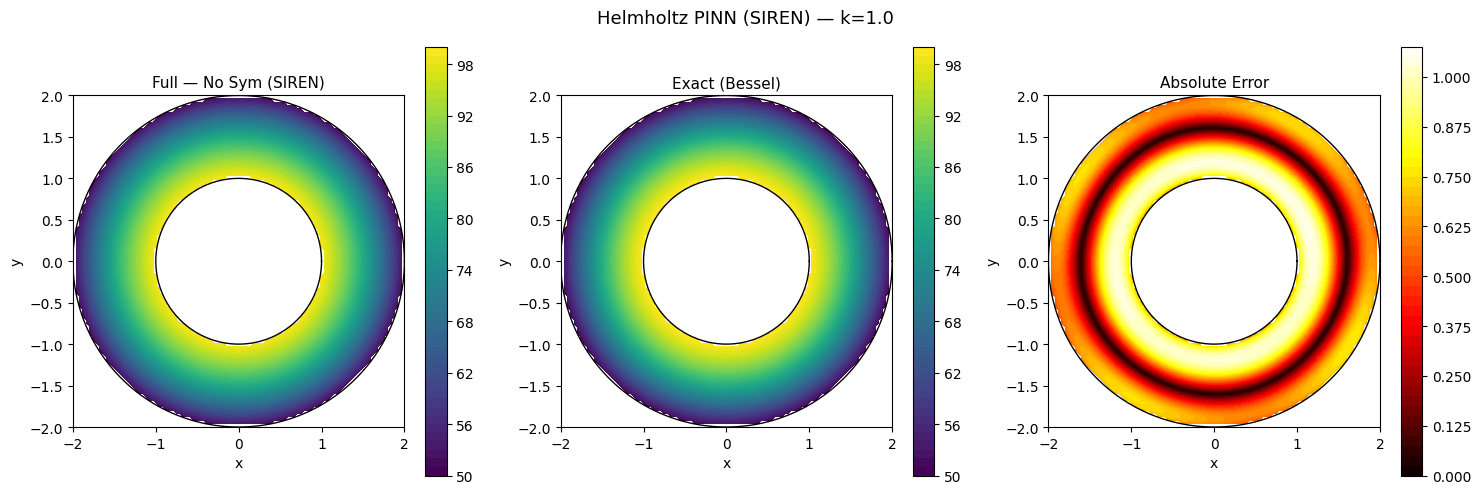

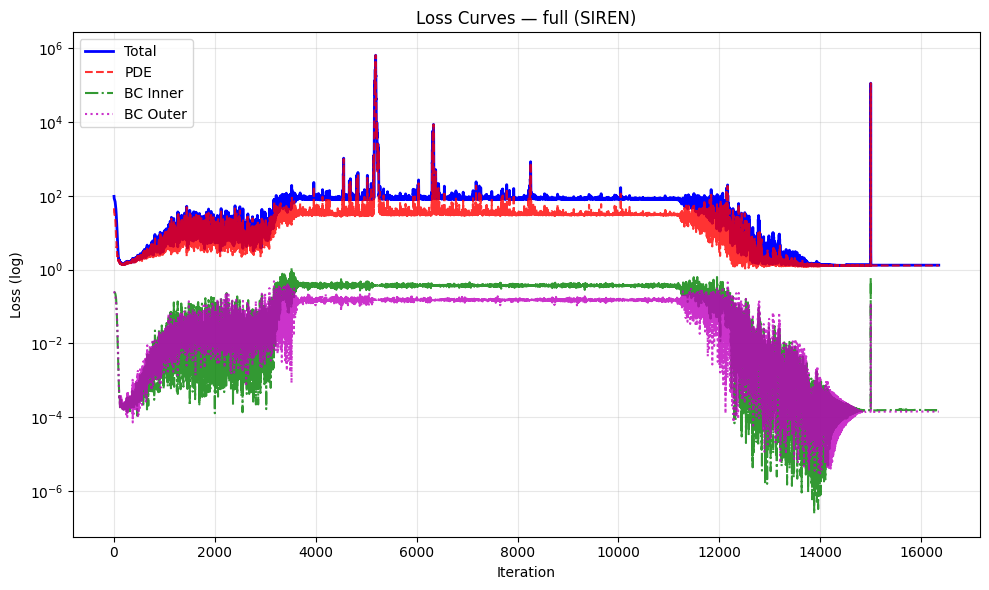

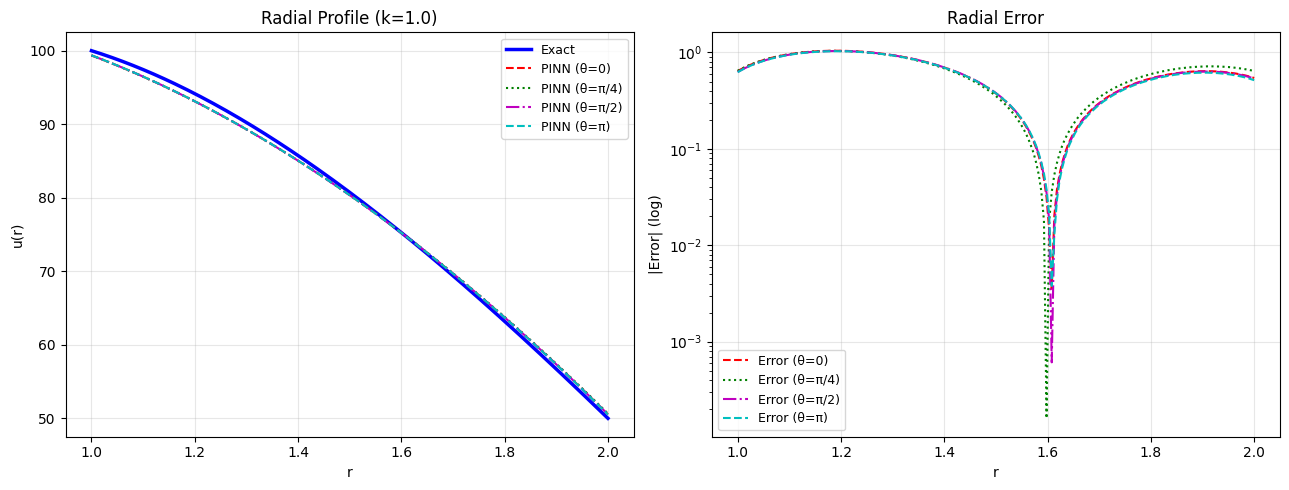

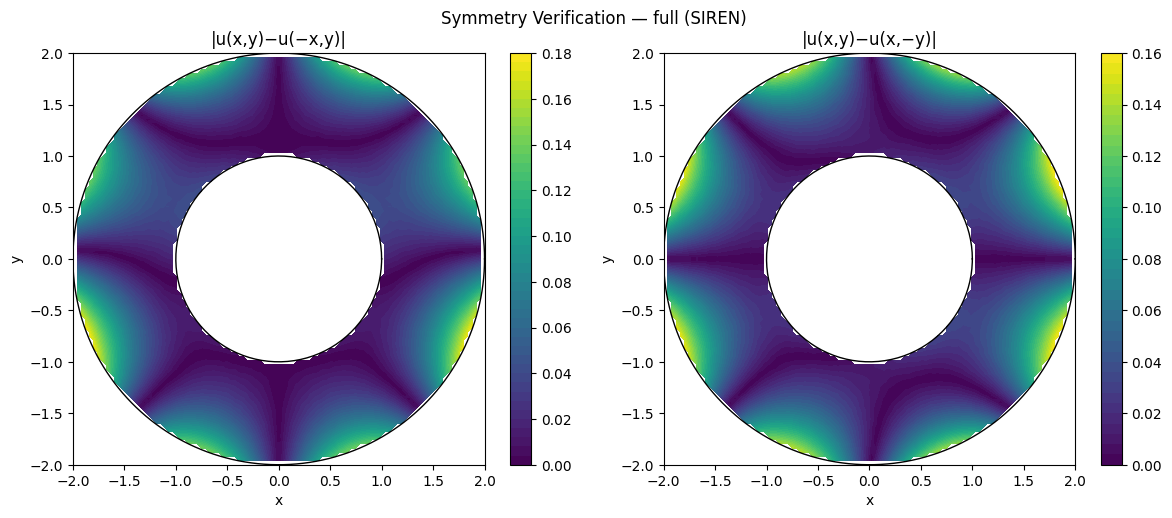

In [ ]:

model, history, abs_err, rel_err, t = run_helmholtz_pinn(
    architecture="full",
    k=1.0,
    hidden_layers=4,
    neurons_per_layer=64,      # Larger network
    omega_0=10.0,              # Lower frequency for smoother solution
    adam_iterations=15000,     # More iterations
    lbfgs_iterations=5000,
    adam_lr=5e-4,
    lambda_pde=1.0,
    lambda_bc=100.0,           # Higher BC weight
    show_plots=True,
)

## -------------------------------------------------------------------------
## 2. QUARTER GEOMETRY + NEUMANN BCs
## -------------------------------------------------------------------------


######################################################################
# ARCHITECTURE: quarter
######################################################################


Configuration (Helmholtz — SIREN):
Architecture : quarter (Quarter Geometry + Neumann BCs)
Geometry     : R1=1.0, R2=2.0
Wavenumber   : k=1.0
BCs          : u_inner=100.0, u_outer=50.0
Network      : 4 layers x 64 neurons
Activation   : SIREN (omega_0=10.0)
Training     : Adam(15000) -> L-BFGS(5000)
Adam LR      : 0.0005
Weights      : lambda_pde=1.0, lambda_bc=100.0, lambda_symm=10.0
Points       : interior=750, bc_inner=125, bc_outer=125
Device       : cpu

Model parameters: 12,737

Phase 1: Adam Optimisation (SIREN)
Iter     0 | Loss: 1.04e+02 | PDE: 5.00e+01 | BC_in: 2.59e-01 | BC_out: 2.58e-01 | Neu: 2.68e-02 | LR: 2.0e-04
Iter  1000 | Loss: 7.90e+00 | PDE: 3.68e+00 | BC_in: 1.07e-03 | BC_out: 2.40e-02 | Neu: 1.72e-02 | LR: 3.8e-03
Iter  2000 | Loss: 9.32e+01 | PDE: 3.71e+01 | BC_in: 3.78e-01 | BC_out: 1.49e-01 | N

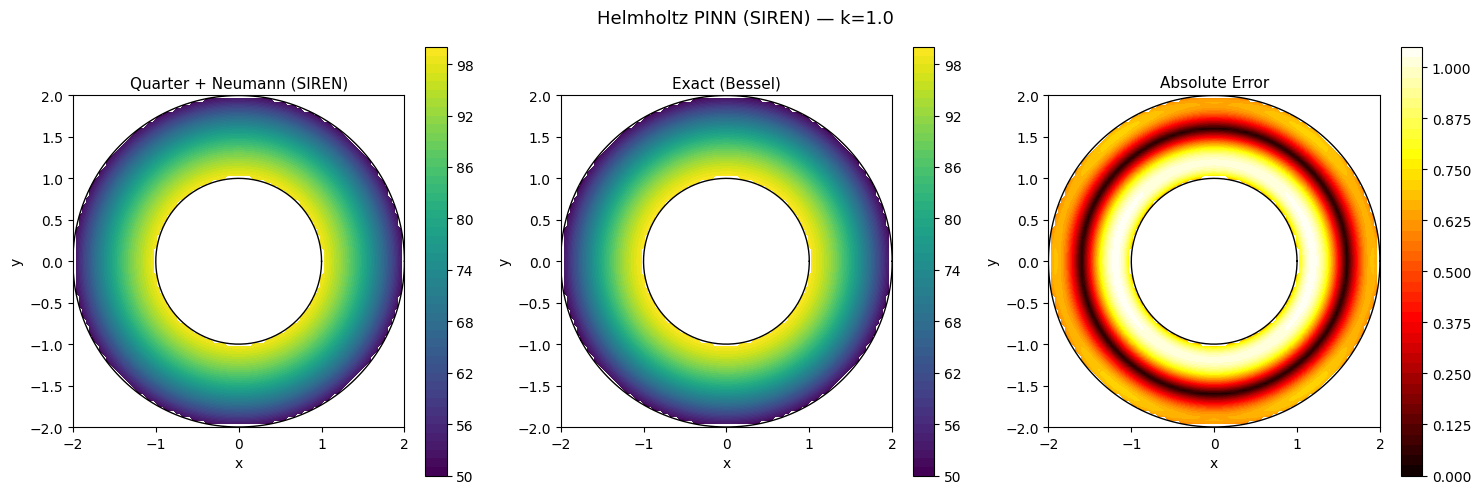

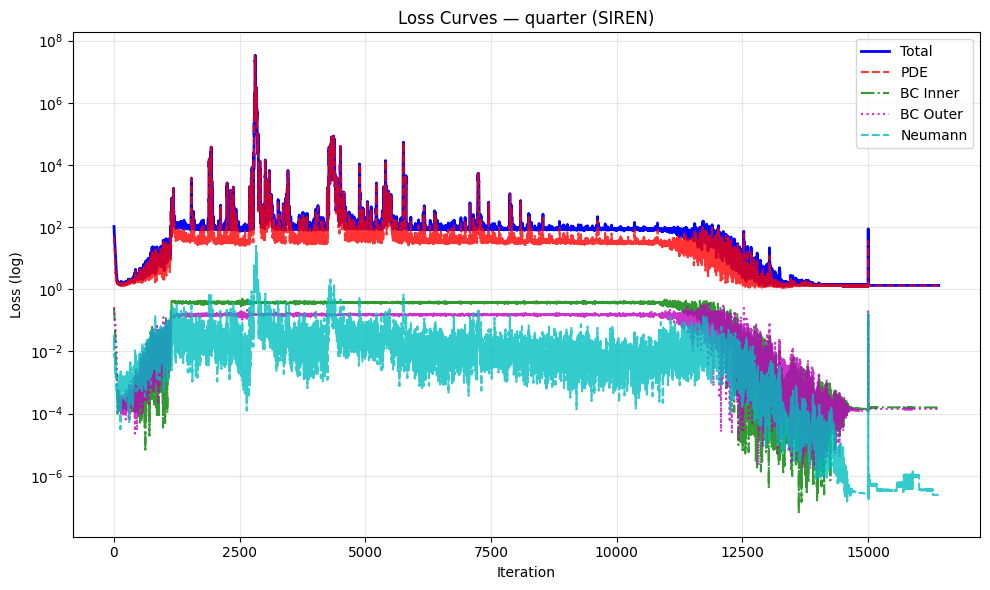

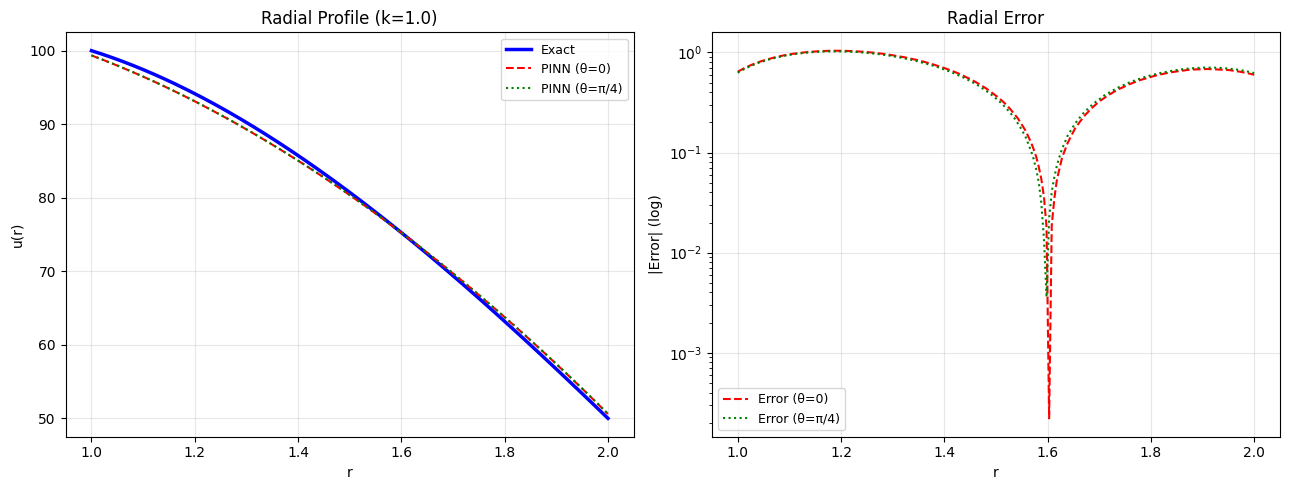

In [ ]:
print("\n" + "#"*70)
print("# ARCHITECTURE: quarter")
print("#"*70 + "\n")

model_quarter, history_quarter, abs_err_quarter, rel_err_quarter, t_quarter = run_helmholtz_pinn(
    architecture="quarter",
    k=1.0,
    hidden_layers=4,
    neurons_per_layer=64,
    omega_0=10.0,
    adam_iterations=15000,
    lbfgs_iterations=5000,
    adam_lr=5e-4,
    lambda_pde=1.0,
    lambda_bc=100.0,
    lambda_symm=10.0,
    show_plots=True,
)





# -------------------------------------------------------------------------
# 3. QUARTER GEOMETRY + LIE SYMMETRY LOSS
# -------------------------------------------------------------------------


######################################################################
# ARCHITECTURE: quarter_lsymm
######################################################################


Configuration (Helmholtz — SIREN):
Architecture : quarter_lsymm (Quarter Geometry + L_symm Loss)
Geometry     : R1=1.0, R2=2.0
Wavenumber   : k=1.0
BCs          : u_inner=100.0, u_outer=50.0
Network      : 4 layers x 64 neurons
Activation   : SIREN (omega_0=10.0)
Training     : Adam(15000) -> L-BFGS(5000)
Adam LR      : 0.0005
Weights      : lambda_pde=1.0, lambda_bc=100.0, lambda_symm=10.0
Points       : interior=750, bc_inner=125, bc_outer=125
Device       : cpu

Model parameters: 12,737

Phase 1: Adam Optimisation (SIREN)
Iter     0 | Loss: 8.54e+01 | PDE: 3.46e+01 | BC_in: 2.72e-01 | BC_out: 2.35e-01 | Symm: 1.20e-02 | LR: 2.0e-04
Iter  1000 | Loss: 3.32e+01 | PDE: 3.09e+01 | BC_in: 7.48e-03 | BC_out: 1.20e-02 | Symm: 3.98e-02 | LR: 3.8e-03
Iter  2000 | Loss: 3.78e+02 | PDE: 3.26e+02 | BC_in: 3.81e-01 | BC_out

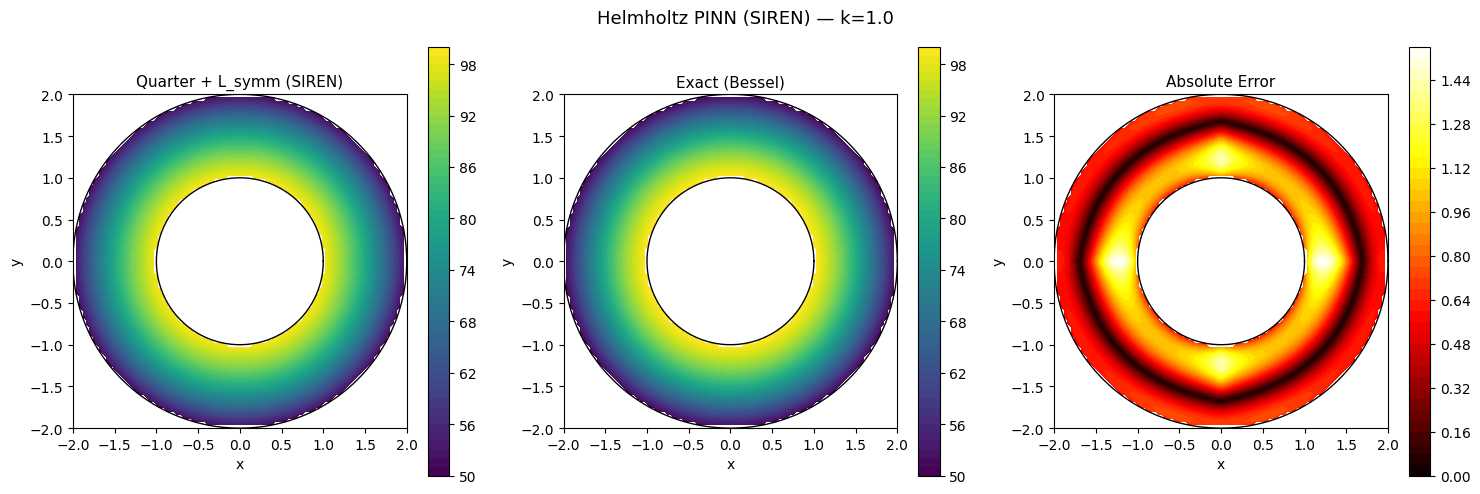

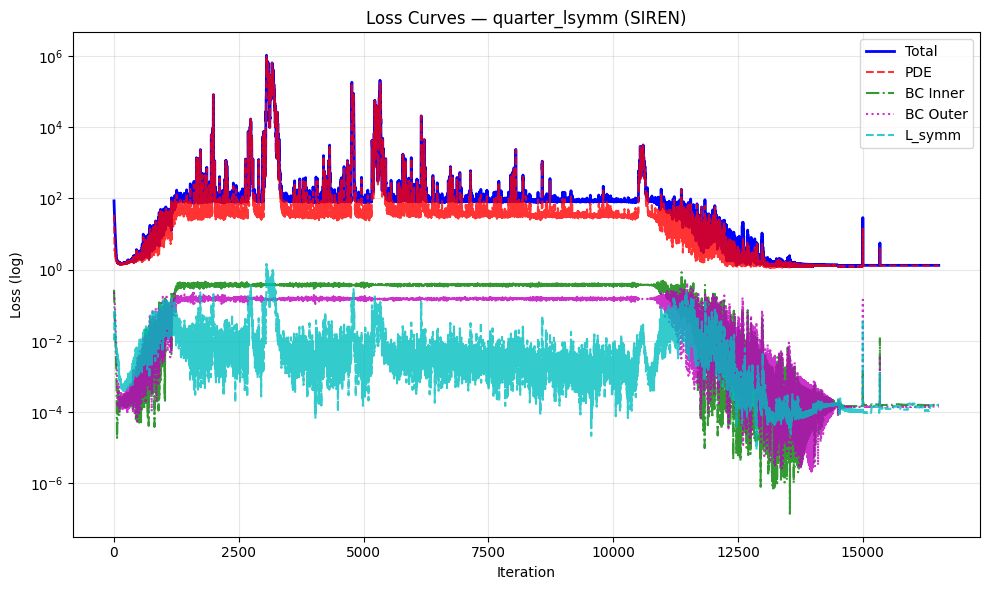

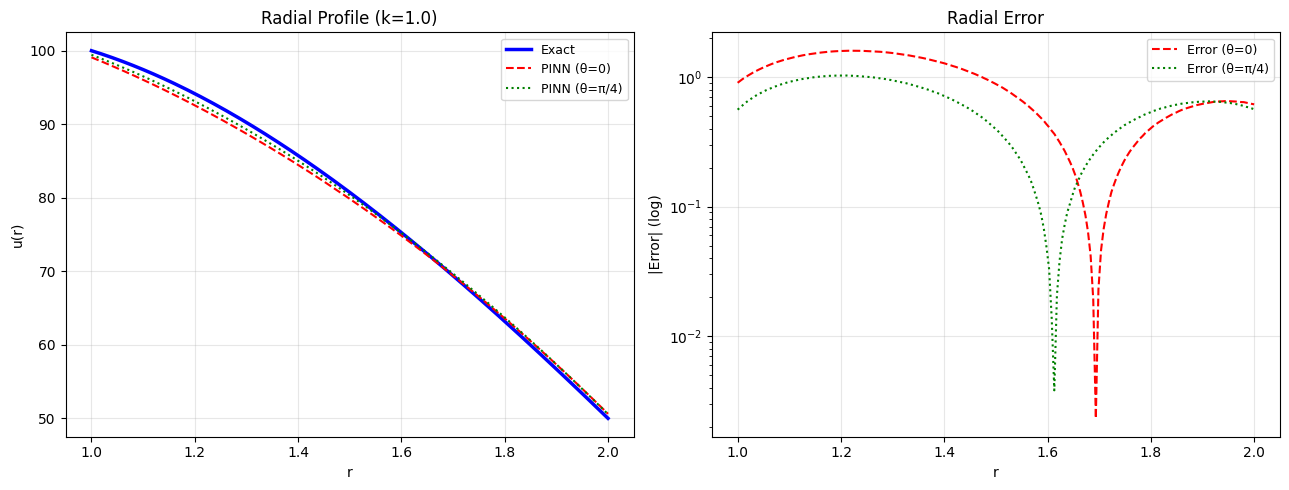

In [ ]:

print("\n" + "#"*70)
print("# ARCHITECTURE: quarter_lsymm")
print("#"*70 + "\n")

model_qlsymm, history_qlsymm, abs_err_qlsymm, rel_err_qlsymm, t_qlsymm = run_helmholtz_pinn(
    architecture="quarter_lsymm",
    k=1.0,
    hidden_layers=4,
    neurons_per_layer=64,
    omega_0=10.0,
    adam_iterations=15000,
    lbfgs_iterations=5000,
    adam_lr=5e-4,
    lambda_pde=1.0,
    lambda_bc=100.0,
    lambda_symm=10.0,
    show_plots=True,
)



# -------------------------------------------------------------------------
# 4. FULL GEOMETRY + 4-FOLD ARCHITECTURAL SYMMETRY
# -------------------------------------------------------------------------


######################################################################
# ARCHITECTURE: full_4fold
######################################################################


Configuration (Helmholtz — SIREN):
Architecture : full_4fold (Full Geometry + 4-fold Architectural Symmetry)
Geometry     : R1=1.0, R2=2.0
Wavenumber   : k=1.0
BCs          : u_inner=100.0, u_outer=50.0
Network      : 4 layers x 64 neurons
Activation   : SIREN (omega_0=10.0)
Training     : Adam(15000) -> L-BFGS(5000)
Adam LR      : 0.0005
Weights      : lambda_pde=1.0, lambda_bc=100.0, lambda_symm=10.0
Points       : interior=2000, bc_inner=300, bc_outer=300
Device       : cpu

Model parameters: 12,737

Phase 1: Adam Optimisation (SIREN)
Iter     0 | Loss: 8.60e+01 | PDE: 3.60e+01 | BC_in: 2.50e-01 | BC_out: 2.50e-01 | LR: 5.0e-04
Iter  1000 | Loss: 1.24e+00 | PDE: 1.21e+00 | BC_in: 1.69e-04 | BC_out: 1.63e-04 | LR: 4.9e-04
Iter  2000 | Loss: 1.36e+00 | PDE: 1.33e+00 | BC_in: 1.48e-04 | BC_out: 1.29e-04 | LR: 4.8e-04

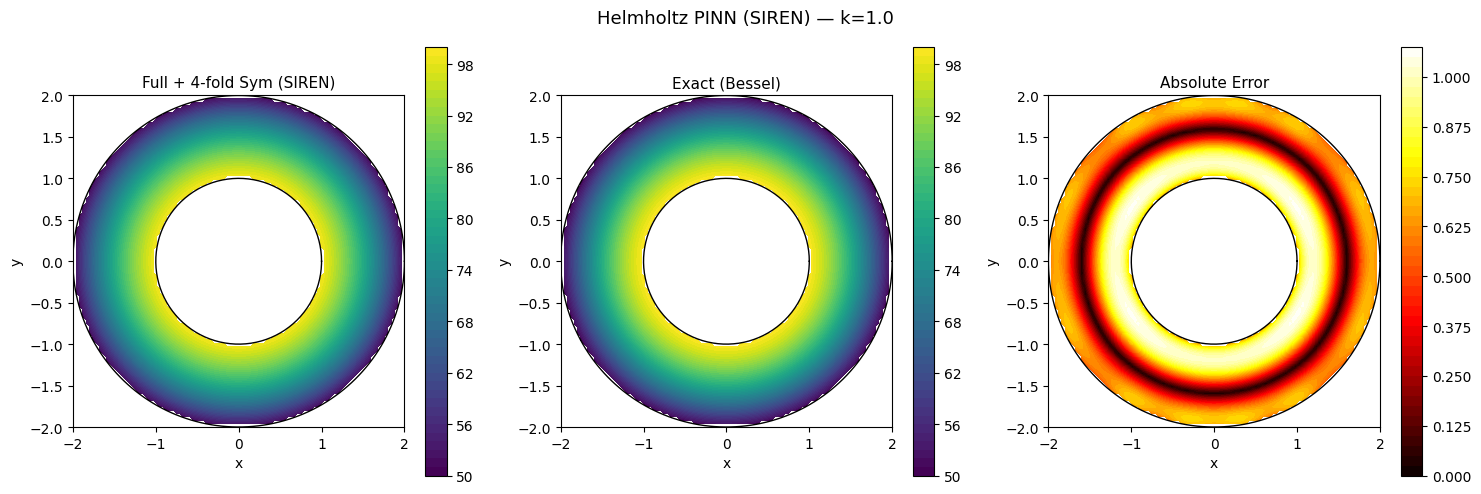

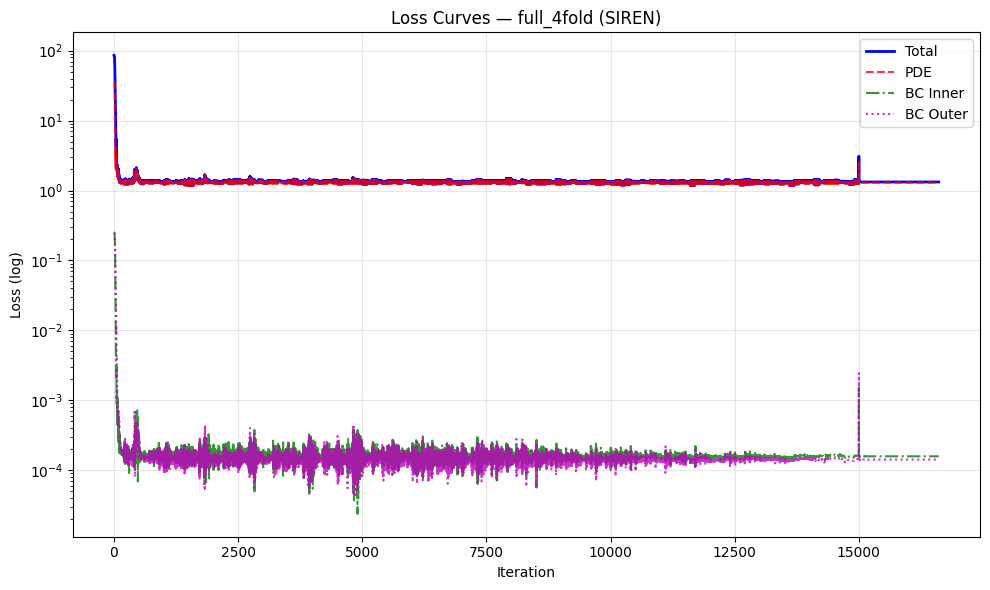

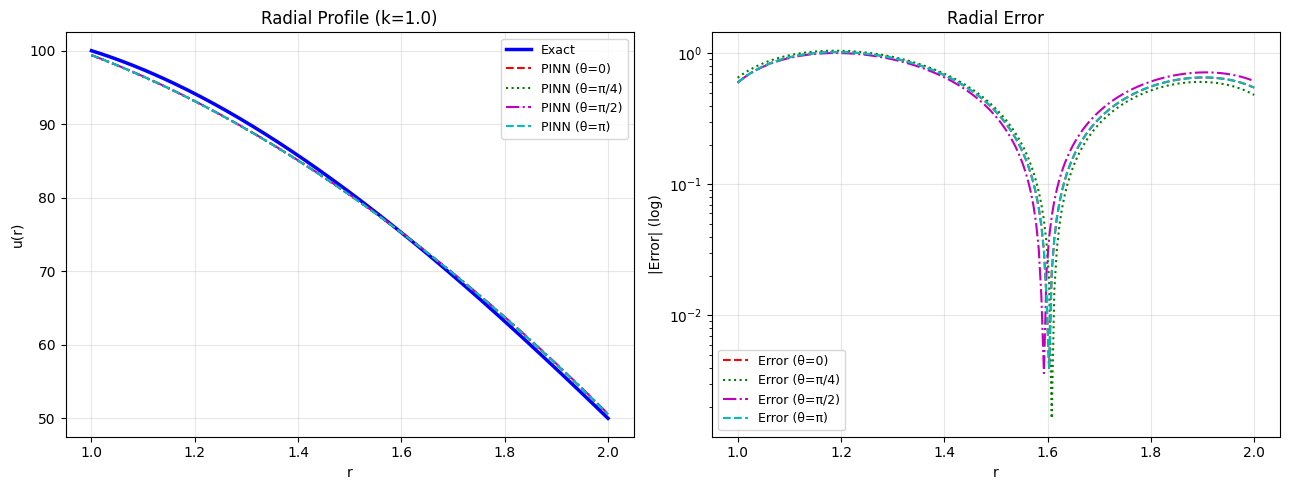

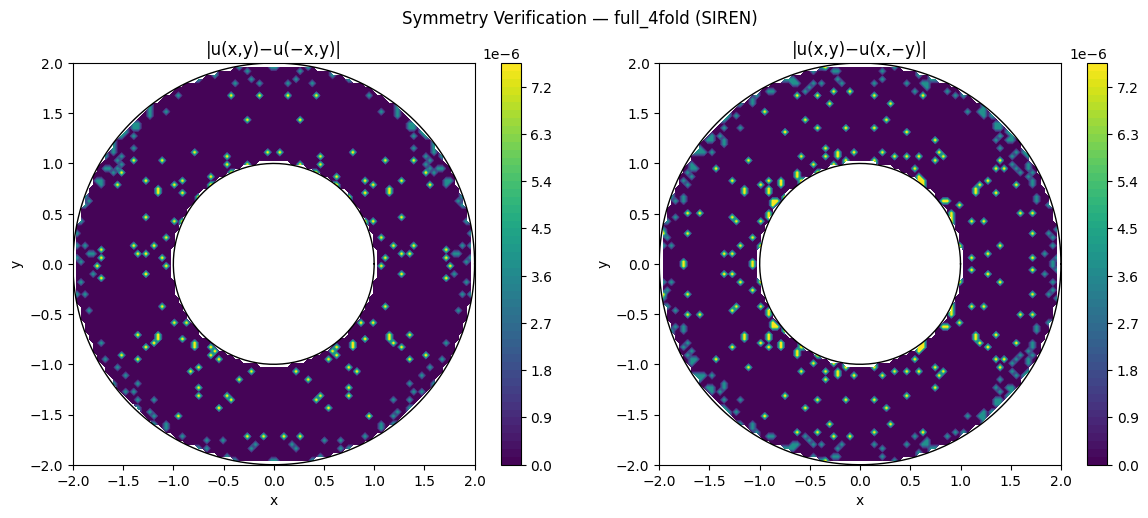

In [ ]:

print("\n" + "#"*70)
print("# ARCHITECTURE: full_4fold")
print("#"*70 + "\n")

model_4fold, history_4fold, abs_err_4fold, rel_err_4fold, t_4fold = run_helmholtz_pinn(
    architecture="full_4fold",
    k=1.0,
    hidden_layers=4,
    neurons_per_layer=64,
    omega_0=10.0,
    adam_iterations=15000,
    lbfgs_iterations=5000,
    adam_lr=5e-4,
    lambda_pde=1.0,
    lambda_bc=100.0,
    lambda_symm=10.0,
    show_plots=True,
)